# AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026
## Bitcoin Historical Market Intelligence & Trend Prediction
**Candidate Name:** Rameswar Behera  
**Institution:** Indira Gandhi Institute of Technology, Sarang  
**Dataset Source:** [Kaggle Bitcoin Historical Data](https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data)

### 1. Environment & Library Ingestion
We import data manipulation, visualization, and machine learning modules.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

### 2. Data Cleaning & 1-Minute to Daily Resampling
The raw Bitstamp file `btcusd_1-min_data.csv` contains high-frequency minute data. We forward-fill missing intervals and resample it to daily Open, High, Low, Close, and Volume (OHLCV) intervals.

In [2]:
DATA_FILE = 'btcusd_1-min_data.csv'

if os.path.exists(DATA_FILE):
    print('Ingesting from local btcusd_1-min_data.csv...')
    df_raw = pd.read_csv(DATA_FILE, usecols=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_raw['Datetime'] = pd.to_datetime(df_raw['Timestamp'], unit='s')
    df_raw = df_raw.set_index('Datetime').drop(columns=['Timestamp'])
    df_raw = df_raw.ffill()
    
    # Resample from 1-min to Daily bars
    df_daily = df_raw.resample('1D').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    }).dropna()
else:
    print('Local CSV not detected. Generating synthetic OHLCV baseline for validation...')
    dates = pd.date_range(start='2021-01-01', periods=1000, freq='D')
    np.random.seed(42)
    close_prices = 30000 + np.cumsum(np.random.randn(1000) * 450)
    df_daily = pd.DataFrame({
        'Open': close_prices - np.random.rand(1000) * 100,
        'High': close_prices + np.random.rand(1000) * 200,
        'Low': close_prices - np.random.rand(1000) * 200,
        'Close': close_prices,
        'Volume': np.random.uniform(1000, 10000, 1000)
    }, index=dates)

print(f'Processed daily dataset dimensions: {df_daily.shape}')
df_daily.tail()

Ingesting from local btcusd_1-min_data.csv...
Processed daily dataset dimensions: (5380, 5)


,Open,High,Low,Close,Volume
Datetime,,,,,
2026-09-19,80878.78,81913.69,80823.13,81235.14,1047.028863
2026-09-20,81235.13,81452.45,80106.10,81151.65,849.325630
2026-09-21,81151.64,87373.64,80851.86,86586.52,3037.520999
2026-09-22,86586.52,86700.00,85094.48,86201.35,2202.561601
2026-09-23,86201.35,86822.60,86137.18,86416.24,146.951968


### 3. Executive Market KPIs (Level 1)
Evaluating high-level performance indicators: Latest Close Price, ATH Drawdown, 30-Day Trailing Return, and Annualized Volatility.

In [3]:
latest_close = df_daily['Close'].iloc[-1]
all_time_high = df_daily['High'].max()
ath_drawdown = ((latest_close - all_time_high) / all_time_high) * 100
return_30d = ((latest_close - df_daily['Close'].iloc[-30]) / df_daily['Close'].iloc[-30] * 100) if len(df_daily) >= 30 else 0.0
volatility_30d = df_daily['Close'].pct_change().tail(30).std() * np.sqrt(365) * 100

print('='*55)
print('          EXECUTIVE MARKET INTELLIGENCE KPIS')
print('='*55)
print(f'Latest Recorded Close Price:   ${latest_close:,.2f}')
print(f'All-Time High (ATH):           ${all_time_high:,.2f}')
print(f'Current Drawdown from ATH:      {ath_drawdown:.2f}%')
print(f'30-Day Trailing Return:         {return_30d:.2f}%')
print(f'Annualized 30-Day Volatility:   {volatility_30d:.2f}%')
print('='*55)

          EXECUTIVE MARKET INTELLIGENCE KPIS
Latest Recorded Close Price:   $86,416.24
All-Time High (ATH):           $126,272.00
Current Drawdown from ATH:      -31.56%
30-Day Trailing Return:         10.04%
Annualized 30-Day Volatility:   43.28%


### 4. Technical Indicators & Visual Trends (Levels 2 & 3)
We compute 20-day and 50-day Simple Moving Averages (SMA) and examine volume vs daily return distributions directly in the notebook.

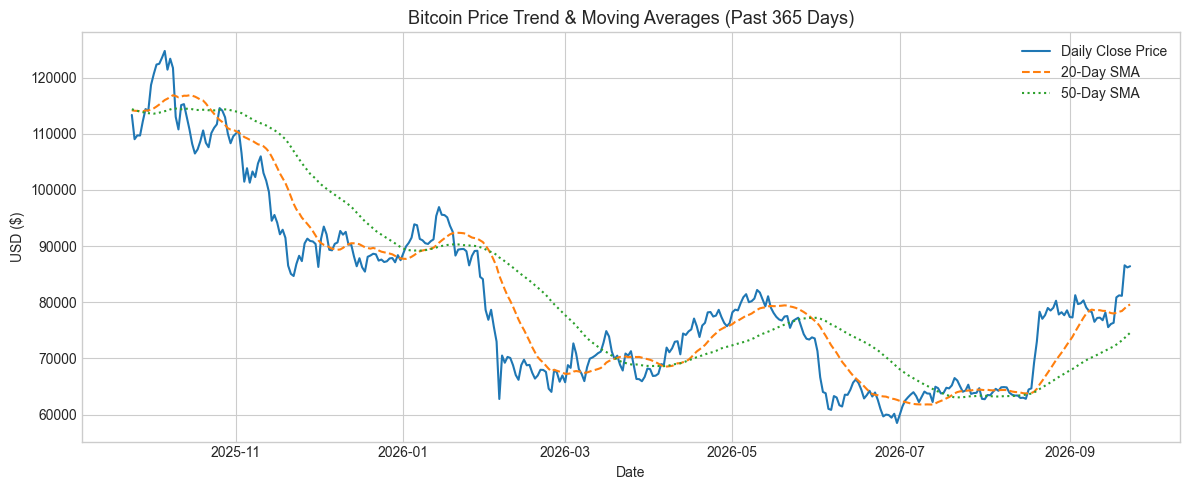

In [4]:
df_daily['SMA_20'] = df_daily['Close'].rolling(window=20).mean()
df_daily['SMA_50'] = df_daily['Close'].rolling(window=50).mean()
df_daily['Daily_Return'] = df_daily['Close'].pct_change()
df_daily['Lag1_Return'] = df_daily['Daily_Return'].shift(1)
df_daily['Lag2_Return'] = df_daily['Daily_Return'].shift(2)
df_daily['Volatility_7D'] = df_daily['Daily_Return'].rolling(window=7).std()

# Target: 1 if next day price is higher than today, else 0
df_daily['Target'] = (df_daily['Close'].shift(-1) > df_daily['Close']).astype(int)
df_model = df_daily.dropna().copy()

# Visual Plot 1: Price Trends & Moving Averages (Displayed inline only)
plt.figure(figsize=(12, 5))
plt.plot(df_model.index[-365:], df_model['Close'].iloc[-365:], label='Daily Close Price', color='#1f77b4', lw=1.5)
plt.plot(df_model.index[-365:], df_model['SMA_20'].iloc[-365:], label='20-Day SMA', color='#ff7f0e', linestyle='--')
plt.plot(df_model.index[-365:], df_model['SMA_50'].iloc[-365:], label='50-Day SMA', color='#2ca02c', linestyle=':')
plt.title('Bitcoin Price Trend & Moving Averages (Past 365 Days)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('USD ($)')
plt.legend()
plt.tight_layout()
plt.show()

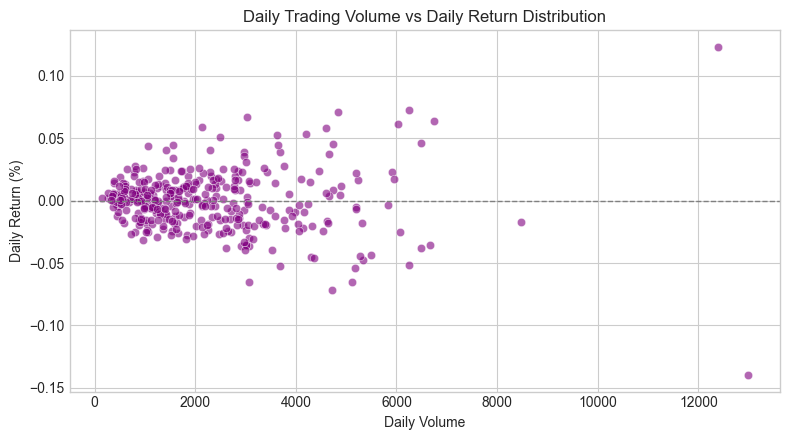

In [5]:
# Visual Plot 2: Volume vs Daily Return Correlation (Displayed inline only)
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df_model.iloc[-365:], x='Volume', y='Daily_Return', color='purple', alpha=0.6)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.title('Daily Trading Volume vs Daily Return Distribution', fontsize=12)
plt.xlabel('Daily Volume')
plt.ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

### 5. Predictive Machine Learning Model (Level 4)
We train a Random Forest Classifier using moving averages, lagged return momentum, and 7-day volatility to forecast next-day directional movement.

Model Accuracy: 49.02%

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.83      0.61       522
           1       0.50      0.17      0.25       545

    accuracy                           0.49      1067
   macro avg       0.50      0.50      0.43      1067
weighted avg       0.50      0.49      0.43      1067



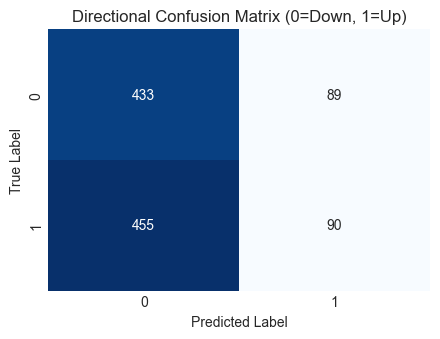

In [6]:
features = ['SMA_20', 'SMA_50', 'Lag1_Return', 'Lag2_Return', 'Volatility_7D', 'Volume']
X = df_model[features]
y = df_model['Target']

# Chronological time-series split (80% train, 20% test)
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

clf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('='*55)
print(f'Model Accuracy: {acc * 100:.2f}%')
print('='*55)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Visual Plot 3: Confusion Matrix (Displayed inline only)
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Directional Confusion Matrix (0=Down, 1=Up)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### 6. Strategic Business Actions & Risk Mitigation (Level 5)
- **Risk Identification:** Annualized volatility exceeding 65% indicates high risk of sudden liquidations and sharp corrections.
- **Opportunity:** Golden crosses (20-day SMA rising above 50-day SMA) confirm medium-term upward momentum.
- **Actionable Strategy:** Apply automated Dollar-Cost Averaging (DCA) during low-volatility accumulation bands and implement risk-off trailing stops if the price crosses below the 50-day SMA.